In [18]:
# This is the same as the main.py
import os
import sys

import matplotlib
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
datapath = '/Users/mobbywang/Downloads/HV20/diastole/M123/'
data_zip_file = os.path.join(datapath, 'diffusion_images','data.gz')

data = pd.read_pickle(data_zip_file, compression="gzip")

image_path = os.path.join(datapath, 'diffusion_images', "images.h5")

with h5py.File(image_path, "r") as hf:
    image_pixel_values = np.array(hf["pixel_values"])  # or hf["pixel_values"][:]

In [20]:
data.keys(),  image_pixel_values.shape

(Index(['file_name', 'b_value', 'direction', 'image_position',
        'nominal_interval', 'acquisition_time', 'acquisition_date',
        'dir_in_image_plane', 'series_description', 'series_number', 'header'],
       dtype='object'),
 (98, 256, 96))

In [21]:
b_values = data['b_value']

In [22]:
# if the bvalue is smaller than 100, put them in one group, otherwise in another
# get the index
low_b_value_indices = np.where(b_values < 100)[0]
high_b_value_indices = np.where(b_values >= 100)[0]

print(low_b_value_indices, high_b_value_indices)

[ 0  7 14 21 28 35 42 49 56 63 70 77 84 85 86 87 88 89 90 91 92 93 94 95
 96 97] [ 1  2  3  4  5  6  8  9 10 11 12 13 15 16 17 18 19 20 22 23 24 25 26 27
 29 30 31 32 33 34 36 37 38 39 40 41 43 44 45 46 47 48 50 51 52 53 54 55
 57 58 59 60 61 62 64 65 66 67 68 69 71 72 73 74 75 76 78 79 80 81 82 83]


In [23]:
low_b_value_images = image_pixel_values[low_b_value_indices]
high_b_value_images = image_pixel_values[high_b_value_indices]

In [24]:
print(len(low_b_value_images), len(high_b_value_images))

26 72


In [29]:
import math

def plot_image_grid(images, title="Image Grid"):
    images = np.array(images)  # [N, H, W]
    num_images = images.shape[0]
    
    # Determine grid size (rows × cols)
    cols = math.ceil(np.sqrt(num_images))
    rows = math.ceil(num_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(rows * cols):
        ax = axes[i]
        if i < num_images:
            nx, ny = images[i].shape
            if nx > ny:
                ax.imshow(images[i][nx//2-48:nx//2+48], cmap='gray')
            elif ny > nx:
                ax.imshow(images[i][:, ny//2-48, ny//2+48], cmap='gray')
            
            ax.axis("off")
        else:
            ax.axis("off")  # hide unused subplot

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

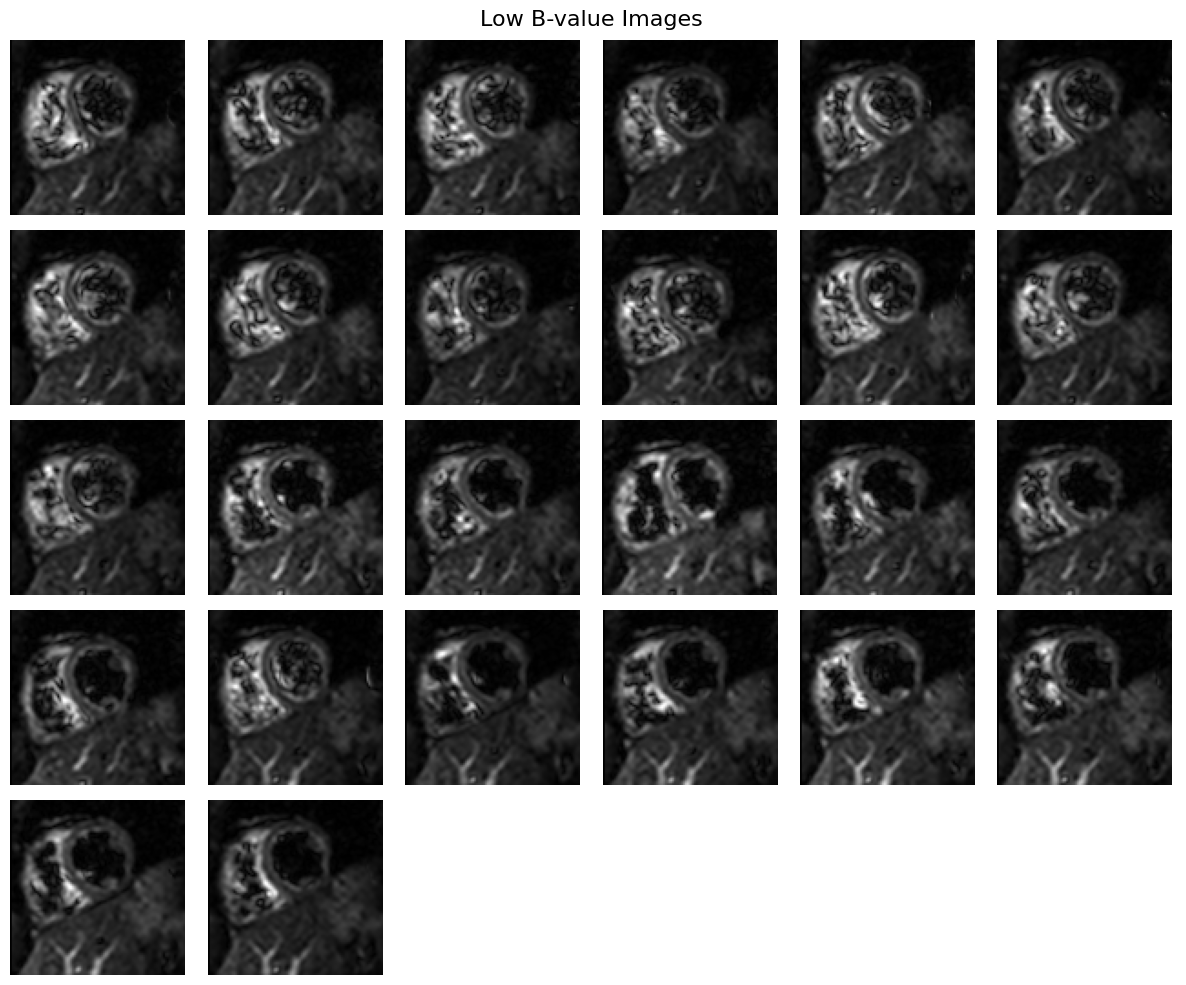

In [30]:
plot_image_grid(low_b_value_images, title="Low B-value Images")

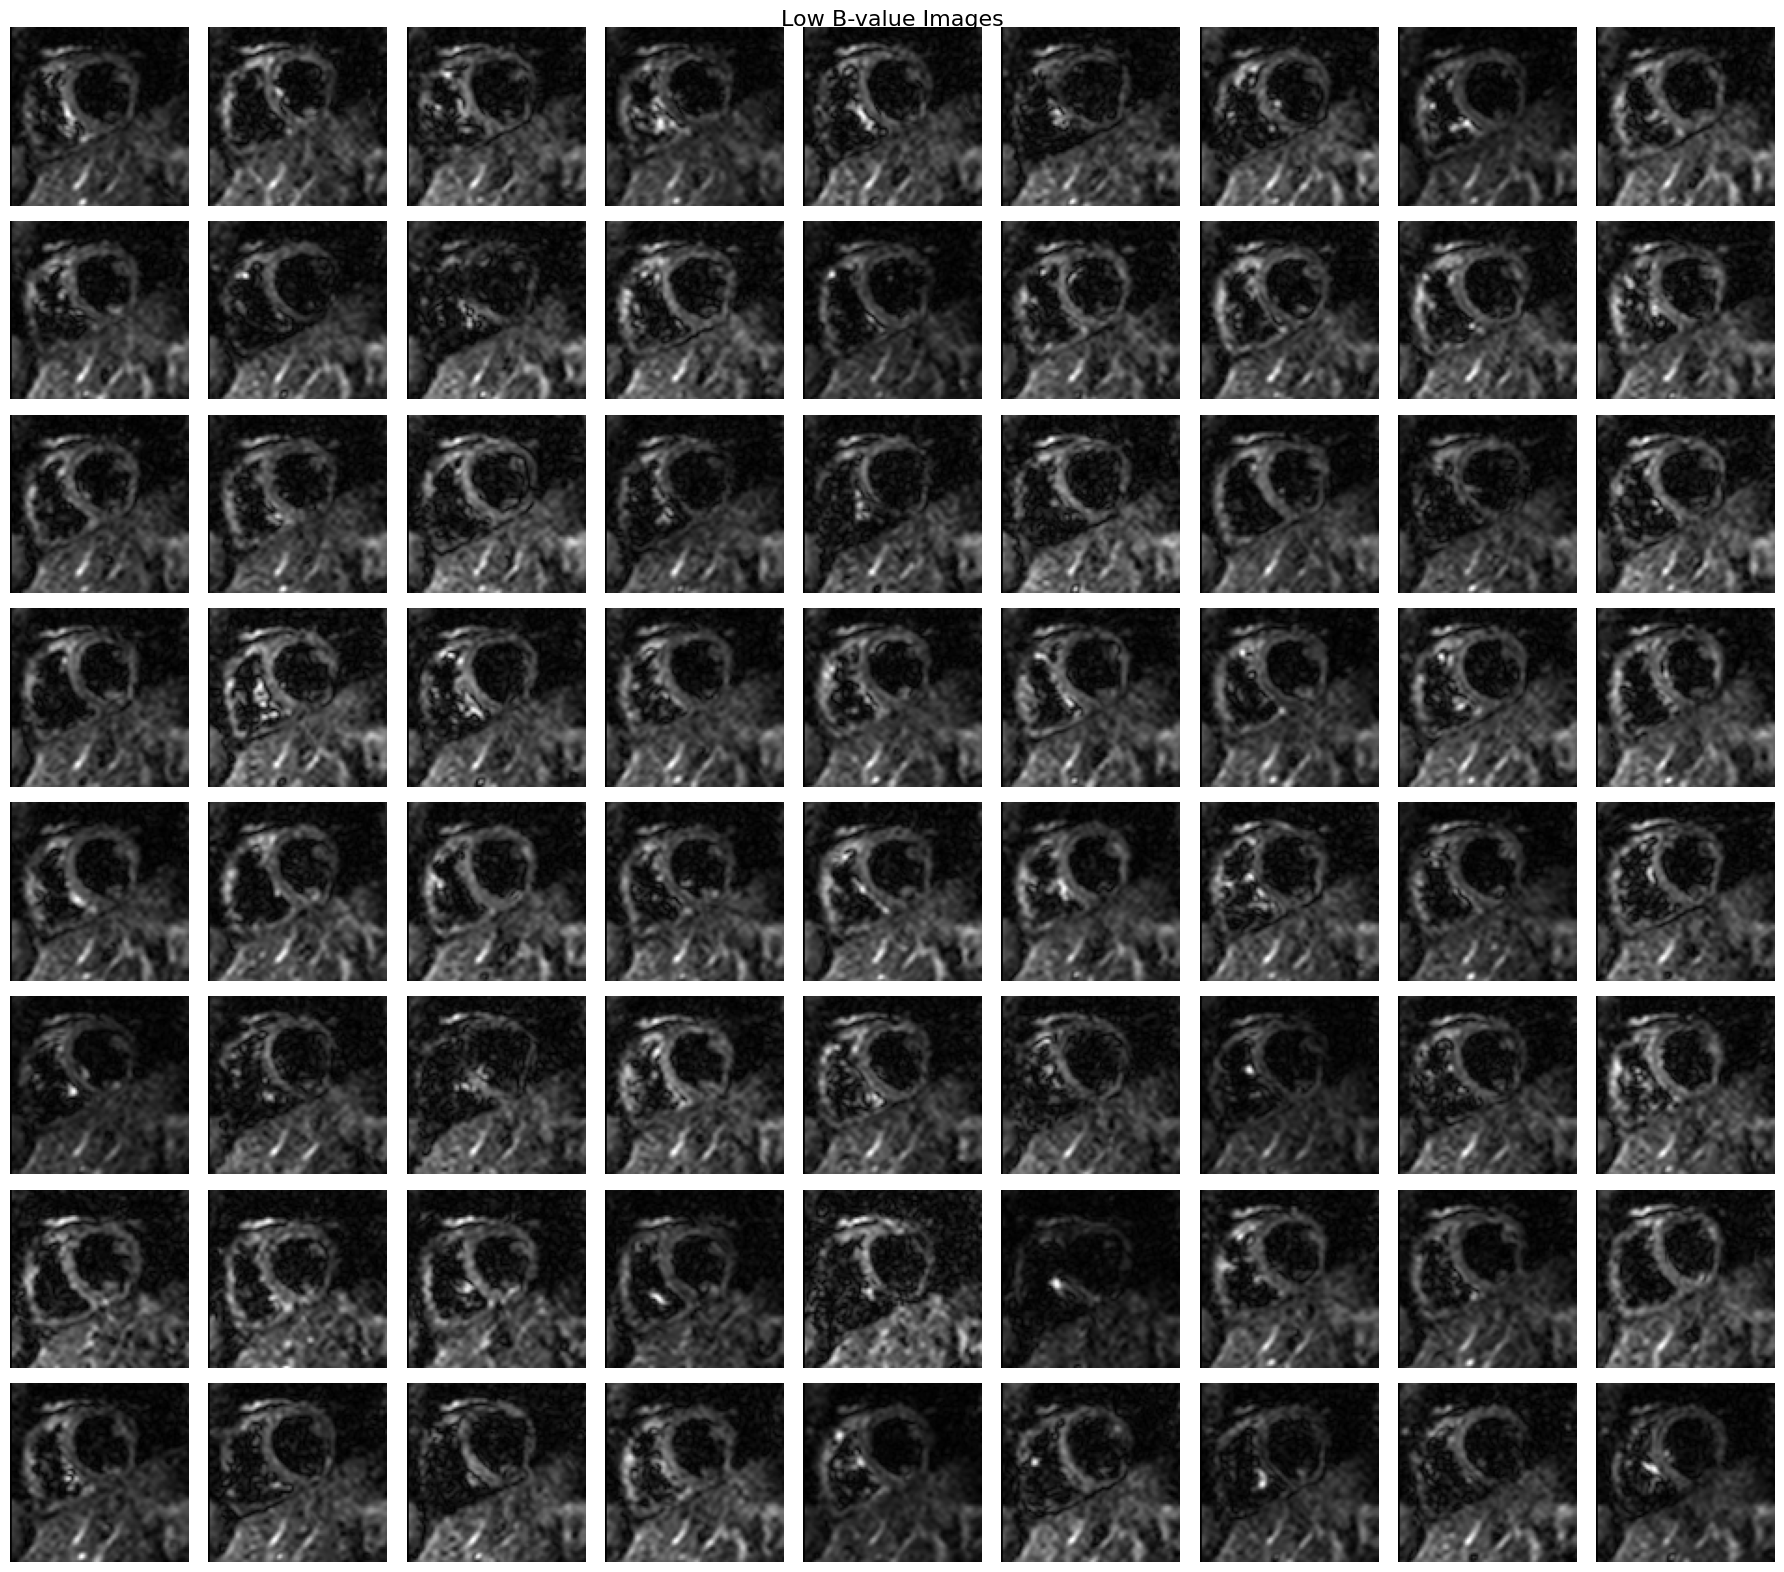

In [ ]:
plot_image_grid(high_b_value_images, title="High B-value Images")

In [ ]:
# generate the 